# Problem Set 3

### Before You Start

This problem set is fun but challenging. It's going to involve a good amount of debugging and head-scratching, so try to start sooner rather than later!

This problem set has three parts:

- **Part I**: Experimental Setup
- **Part II**: Nearest Neighbor and Cross-Validation
- **Part III**: Overfitting in Model Selection and Nested Cross Validation

For part I and II we'll consider a regression problem. You should *not* be using any built-in ML libraries for nearest neighbors, distance metrics, or cross-validation -- your mission is to write those algorithms in Python! For these two first parts we will be working with a modified version of the California Housing Dataset that you can download from bcourses (`cal_housing_data_clean.csv`). Part I will be relatively easy; Part II will take more time.

For part III we'll consider a classification problem. You'll be able to use Python ML built-in libraries (in particular scikit-learn). We'll not be using the California Housing Dataset but rather synthetic data that you'll generate yourself. 

Make sure the following libraries load correctly before starting (hit Ctrl-Enter).

In [137]:
import IPython
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib
import sklearn
import time

In [138]:
%matplotlib inline  
import matplotlib.pyplot as plt  

---

## Introduction to the assignment

For this assignment, you will be using a version of the [California Housing Prices Dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset) with additional information. Use the following commands to load the information in the csv file provided with the assignment in bcourses (`cal_housing_data_clean.csv`). Take some time to explore the data. 

In [139]:
# load Cal data set
cal_df = pd.read_csv('cal_housing_data_clean.csv')
features = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','DistCoast','Inland']
target = 'MedHouseVal'

In [140]:
cal_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,DistCoast,Inland,MedHouseVal
0,3.6885,49,5.184569,1.052950,2363,3.574887,4205.460788,0,2.540
1,3.5444,12,4.786854,1.027230,2029,1.905164,72365.363970,1,1.325
2,4.2011,9,6.045161,1.038710,1955,3.153226,166848.071800,1,1.081
3,3.1630,26,4.267241,0.961207,719,3.099138,28060.624020,0,1.794
4,4.6197,21,3.701933,1.019329,1489,1.514751,5593.110112,0,3.875


---

# Part I: Experimental Setup

The goal of the next few sections is to design an experiment to predict the median home value for census block groups.
Before beginning the "real" work, refamiliarize yourself with the dataset.

### 1.1 Begin by writing a function to compute the Root Mean Squared Error for a list of numbers

You can find the sqrt function in the Numpy package. Furthermore the details of RMSE can be found on [Wikipedia](http://en.wikipedia.org/wiki/Root-mean-square_deviation). Do not use a built-in function  to compute RMSE, other than numpy functions like `sqrt` and if needed, `sum` or other relevant ones.

In [141]:
"""
Function
--------
compute_rmse

Given two arrays, one of actual values and one of predicted values,
compute the Root Mean Squared Error

Parameters
----------
y_hat : array
    numpy array of numerical values corresponding to predictions for each of the N observations

y : array
    numpy array of numerical values corresponding to the actual values for each of the N observations

Returns
-------
rmse : float
    Root Mean Squared Error of the prediction

Example
-------
>>> print(compute_rmse((4,6,3),(2,1,4)))
3.16
"""
def compute_rmse(y, y_hat):
    rmse = np.sqrt(np.sum((y - y_hat)**2)/len(y))
    return rmse


In [142]:
# Example rmse calculation 
compute_rmse(np.array([4,6,3]),np.array([2,1,4]))

3.1622776601683795

### 1.2 Divide your data into training and testing datasets

Randomly select 75% of the data and put this in a training dataset (call this "cal_df_train"), and place the remaining 25% in a testing dataset (call this "cal_df_test"). Do not use built-in functions.

To perform any randomized operation, only use functions in the *numpy library (np.random)*. Do not use other packages for random functions.

In [143]:
# leave the following line untouched, it will help ensure that your "random" split is the same "random" split used by the rest of the class
np.random.seed(seed=1948)

# define training / test proportion split
train_percent = .75
train_num = int(len(cal_df)*train_percent)
test_num = len(cal_df) - train_num 

# shuffle df ids
ids = np.arange(0, len(cal_df), 1)
np.random.shuffle(ids)
cal_df_shuffled = cal_df.iloc[ids]

cal_df_train = cal_df_shuffled[:train_num]
cal_df_test = cal_df_shuffled[train_num:]


### 1.3 Use a baseline for prediction, and compute RMSE 

Let's start by creating a very bad baseline model that predicts median house values as the average of `MedHouseVal`.

Specifically, create a model that predicts, for every observation X_i, the median home value as the average of the median home values of block groups in the **training set**.

Once the model is built, do the following:

1. Report the RMSE of the training set and report it.
2. Report the RMSE of the test data set (but use the model you trained on the training set!).
3. How does RMSE compare for training vs. testing datasets? Is this what you expected, and why?
4. Add code to your function to measure the running time of your algorithm. How long does it take to compute the predicted values for the test data?
5. Create a scatter plot that shows the true value of each instance on the x-axis and the predicted value of each instance on the y-axis. Color the training instances in blue and the test instances in gold. Make sure to label your axes appropriately, and add a legend to your figure.

run time:0.00023484230041503906
run time:0.0006961822509765625
RMSE training data set: 1.1560706527361215
RMSE test data set: 1.1474775264840165


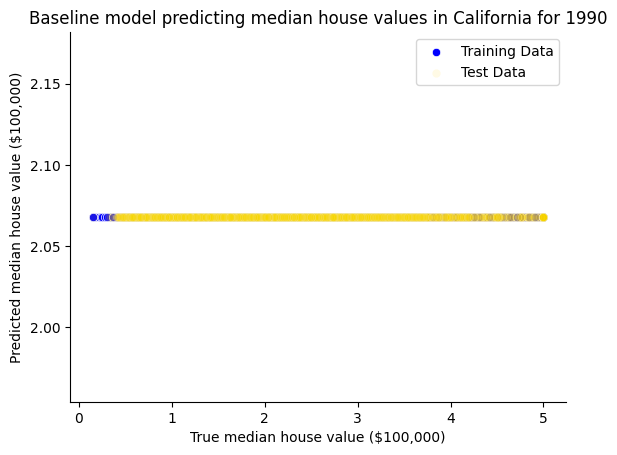

In [145]:
# your code here
from sklearn.linear_model import LinearRegression
import time
import seaborn as sns

# Define baseline prediction model 
def median_home_value_model(cal_df_train, cal_df_test):
    # record start time of code 
    start_time = time.time()

    # compute model 
    avg_med_home_val = cal_df_train['MedHouseVal'].mean()
    y_hat = pd.Series(avg_med_home_val, index=cal_df_test.index)

    # record end time and compute run time 
    end_time = time.time()
    runtime = end_time - start_time
    print('run time:' + str(runtime))

    return y_hat

# run model 
cal_df_test_hat = median_home_value_model(cal_df_train, cal_df_test)

# 1. RMSE of training set 
cal_df_train_hat = median_home_value_model(cal_df_train, cal_df_train)
RMSE_training = compute_rmse(cal_df_train['MedHouseVal'].values,cal_df_train_hat.values)
print('RMSE training data set: '+ str(RMSE_training))

# 2. RMSE of test set 
RMSE_test = compute_rmse(cal_df_test['MedHouseVal'].values,cal_df_test_hat.values)
print('RMSE test data set: '+ str(RMSE_test))

# 5. Model scatterplot
sns.scatterplot(x = cal_df_train['MedHouseVal'].values, y = cal_df_train_hat.values, color = 'blue', label = 'Training Data')
sns.scatterplot(x = cal_df_test['MedHouseVal'].values, y = cal_df_test_hat.values, color = 'gold', label = 'Test Data', alpha = 0.1)
plt.xlabel('True median house value ($100,000)')
plt.ylabel('Predicted median house value ($100,000)')
plt.title('Baseline model predicting median house values in California for 1990')
sns.despine()
plt.show()



1. Report the RMSE of the training set and report it.
- RMSE training data set: 1.156
2. Report the RMSE of the test data set (but use the model you trained on the training set!).
- RMSE test data set: 1.147
3. How does RMSE compare for training vs. testing datasets? Is this what you expected, and why?
- The RMSE of the test data set is slightly smaller than the training data set. This is unexpected since the size of the training data set is 3 times that of the test data set and the RMSE scales inversely with the size of the data set so we would expect a smaller RMSE for the training data set which is larger. In this case, the distribution of the test data must fit the mean of the train data better by chance. 
4. Add code to your function to measure the running time of your algorithm. How long does it take to compute the predicted values for the test data?
- The run time for the test data set is 0.000241 seconds. 
5. Create a scatter plot that shows the true value of each instance on the x-axis and the predicted value of each instance on the y-axis. Color the training instances in blue and the test instances in gold. Make sure to label your axes appropriately, and add a legend to your figure.
- see above.

### 1.4 Use another baseline for prediction, and compute RMSE [extra-credit]

Now consider a baseline model that predicts median house values as the averages of `MedHouseVal` based on whether the census block is adjacent to the coast or inland (note that the `Inland` feature is already computed and ready for you).

Specifically, create a model that predicts, for every observation X_i, the median home value as the average of the median home values of block groups in the **training set** that have the same adjacency value.

For example, for an input observation where `Inland==1`, the model should predict the `MedHouseVal` as the average of all `MedHouseVal` values in the training set that also have `Inland==1`.

Once the model is built, do the following:

1. Compute the RMSE of the training set.
2. Now compute the RMSE of the test data set (but use the model you trained on the training set!).
3. How does RMSE compare for training vs. testing datasets? Is this what you expected, and why?
4. Add code to your function to measure the running time of your algorithm. How long does it take to compute the predicted values for the test data?
5. Create a scatter plot that shows the true value of each instance on the x-axis and the predicted value of each instance on the y-axis. Color the training instances in blue and the test instances in gold. Make sure to label your axes appropriately, and add a legend to your figure to make clear which dots are which.
6. Compare this results to those obtained in 1.3. Is coast adjacency improving the predictions? 

*Note:* The `groupby` operation might come handy here.

run time:0.004256010055541992
run time:0.0032541751861572266
RMSE training data set: 1.0119036022521926
RMSE test data set: 1.0011137151179164


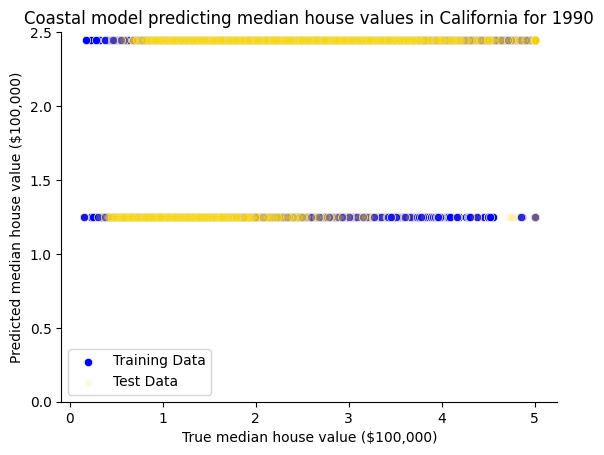

In [147]:
# your code here

# Define baseline prediction model 
def median_home_value_model_coast(cal_df_train, cal_df_test):
    # record start time of code 
    start_time = time.time()

    # compute model 
    avg_med_home_val_inland = cal_df_train[cal_df_train['Inland'] == 1]['MedHouseVal'].mean()
    avg_med_home_val_coast = cal_df_train[cal_df_train['Inland'] == 0]['MedHouseVal'].mean()

    # fill y_hat df 
    y_hat = pd.Series(index=cal_df_test.index, dtype = float)

    # fill for inland blocks 
    inland_idxs = cal_df_test[cal_df_test['Inland'] == 1].index
    y_hat[inland_idxs] = avg_med_home_val_inland

    # fill for coastal blocks 
    coast_idxs = cal_df_test[cal_df_test['Inland'] == 0].index
    y_hat[coast_idxs] = avg_med_home_val_coast

    # record end time and compute run time 
    end_time = time.time()
    runtime = end_time - start_time
    print('run time:' + str(runtime))

    return y_hat

cal_df_test_coast_hat = median_home_value_model_coast(cal_df_train, cal_df_test)

# 1. RMSE of training set 
cal_df_train_coast_hat = median_home_value_model_coast(cal_df_train, cal_df_train)
RMSE_training = compute_rmse(cal_df_train['MedHouseVal'].values,cal_df_train_coast_hat.values)
print('RMSE training data set: '+ str(RMSE_training))

# 2. RMSE of test set 
RMSE_test = compute_rmse(cal_df_test['MedHouseVal'].values,cal_df_test_coast_hat.values)
print('RMSE test data set: '+ str(RMSE_test))

# 5. Model scatterplot
sns.scatterplot(x = cal_df_train['MedHouseVal'].values, y = cal_df_train_coast_hat.values, color = 'blue', label = 'Training Data')
sns.scatterplot(x = cal_df_test['MedHouseVal'].values, y = cal_df_test_coast_hat.values, color = 'gold', label = 'Test Data', alpha = 0.1)
plt.ylim([0,2.5])
plt.xlabel('True median house value ($100,000)')
plt.ylabel('Predicted median house value ($100,000)')
plt.title('Coastal model predicting median house values in California for 1990')
sns.despine()
plt.show()

1. Compute the RMSE of the training set.
- The RMSE of the training set is 1.0119. 
2. Now compute the RMSE of the test data set (but use the model you trained on the training set!).
- The RMSE of the test set is 1.0011. 
3. How does RMSE compare for training vs. testing datasets? Is this what you expected, and why?
- Here the RMSE for the tests data set is also smaller than that of the training data set. This is unexpected since this test data set is held out data not included in the model and the test data set size is much smaller than the training data set. The explanation for this may be that the randomization process was well done and the test data set is an accurate representaiton of the entire data set. 
4. Add code to your function to measure the running time of your algorithm. How long does it take to compute the predicted values for the test data?
- The run time to compute the predicted values for the test data set is 0.004256. 
5. Create a scatter plot that shows the true value of each instance on the x-axis and the predicted value of each instance on the y-axis. Color the training instances in blue and the test instances in gold. Make sure to label your axes appropriately, and add a legend to your figure to make clear which dots are which.
- see above. 
6. Compare this results to those obtained in 1.3. Is coast adjacency improving the predictions? 
- By taking into account coast adjacency in our model, the RMSE of the test data set is now lower (1.147 not included vs 1.0011 included) compared to the baseline model, thereby indicating that our predictions are closer to the true value. The rationale for this is that we are now taking into account more features that may better predict the target variable better, even if we are just assigning the mean value. 

---

# Part II: Nearest Neighbors and Cross-Validation
Let's try and build a machine learning algorithm to beat the "Average Values" baselines that you computed above. Your next task is to implement a basic nearest neighbor algorithm from scratch. 

### 2.1 Nearest Neighbors: Normalization

Create normalized analogues of all the features in both the training and test datasets. Recall that this involves substracting the **training** mean and dividing by the **training** standard deviation. 

Include the normalized features as additional columns in the train an test dataframes and call them 
`MedIncNorm, HouseAgeNorm, AveRoomsNorm, AveBedrmsNorm, PopulationNorm, AveOccupNorm, DistCoastNorm and InlandNorm` respectively.

In [149]:
# intialize df
cal_df_train_norm = pd.DataFrame(index = cal_df_train.index)
cal_df_test_norm = pd.DataFrame(index = cal_df_test.index)

# Calculate mean and standard deviation for each feature
means = cal_df_train.mean()
stds = cal_df_train.std()

# Normalize each feature
for feature in cal_df_train.columns:
    cal_df_train_norm[feature + 'Norm'] = (cal_df_train.loc[:,feature] - means[feature]) / stds[feature]
    cal_df_test_norm[feature + 'Norm'] = (cal_df_test.loc[:,feature] - means[feature]) / stds[feature]


cal_df_train = cal_df_train.merge(cal_df_train_norm, left_index=True, right_index=True)
cal_df_test = cal_df_test.merge(cal_df_test_norm, left_index=True, right_index=True)


### 2.2 Basic Nearest Neighbor algorithm

Use your training data to "fit" your model that predicts `MedHouseVal` from `MedIncNorm`, `HouseAgeNorm` and `AveRoomsNorm`, although as you know, with Nearest Neighbors there is no real training, you just need to keep your training data in memory.  Write a function that predicts the median home value using the nearest neighbor algorithm we discussed in class.  Since this is a small dataset, you can simply compare your test instance to every instance in the training set, and return the `MedHouseVal` value of the closest training instance. Have your function take L as an input, where L is an integer >= 1 representing the norm choice. Use the Euclidean distance (L=2) for all questions henceforth unless explicitly stated otherwise.

Make sure to do the following - 
1. Use your algorithm to predict the median home value of every instance in the test set. Report the RMSE ("test RMSE")
2. Use your algorithm to predict the median home value of every instance in the training set and report the training RMSE.
3. Create a scatter plot that shows the true value of each instance on the x-axis and the predicted value of each instance on the y-axis.
4. Report an estimate of the total time taken by your code to predict the nearest neighbors for all the values in the test data set.
5. How does the performance (test RMSE and total runtime) of your nearest neighbors algorithm compare to the baseline in part 1.3?

**Note:** Runtime should not exceed a couple of minutes. If its taking longer then we strongly suggest you go back to your code and make it more efficient. 

In [150]:
def euclidean_distance(x_train, x_test, L):
    '''
    Inputs:
        x_train: array of training vectors (np.array)
        x_test: single test vector (np.array)
        L: norm choice (int)
    '''

    if L == 1:
        d = np.sum(np.abs(x_train - x_test), axis=1)
    if L >= 1:
        d = np.linalg.norm(x_train - x_test, ord= L, axis=1)
    return d

class NN_model:
    def __init__(self, k=3, L=2):
        '''
        Inputs:
            k = k nearest neighbours to compare to 
            L =  norm choice
        '''

        self.k = k
        self.L = L
    
    def fit(self, x_train, y_train):
        self.x_train = x_train
        self.y_train = y_train
    
    def predict(self, x_test):
        # record start time of code 
        start_time = time.time()
        
        # Initialize predictions
        predictions = []
        for x in x_test:
            # Compute euc dist between x and all instances in training set
            distances = euclidean_distance(self.x_train, x, self.L)
            # Sort distances and return top k neighbors
            k_indices = np.argsort(distances)[:self.k]
            # Use index to predict label
            k_nearest_labels = self.y_train[k_indices]
            predictions.append(np.mean(k_nearest_labels))
        y_hat = np.array(predictions)

        # record end time and compute run time 
        end_time = time.time()
        runtime = end_time - start_time
        print('run time:' + str(runtime))
        
        return y_hat

# convert x,y train and x test to np arrays
x_train = cal_df_train[['MedIncNorm', 'HouseAgeNorm', 'AveRoomsNorm']].values
y_train = cal_df_train['MedHouseVal'].values
x_test = cal_df_test[['MedIncNorm', 'HouseAgeNorm', 'AveRoomsNorm']].values

# Create and fit the model
knn_model = NN_model(k=1, L=2) 
knn_model.fit(x_train, y_train)
y_hat_test = knn_model.predict(x_test)
y_hat_train = knn_model.predict(x_train)



run time:6.1990392208099365
run time:18.60338807106018


RMSE test data set: 1.0350385789713217
RMSE training data set: 0.0


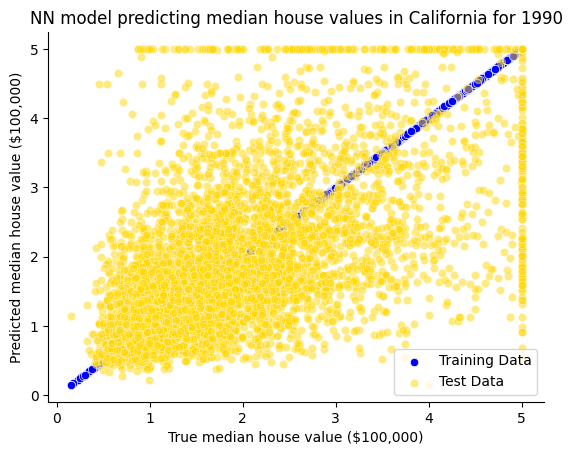

In [151]:
# 1. Test Set
y_test = cal_df_test['MedHouseVal'].values
RMSE_NN_test = compute_rmse(y_test,y_hat_test)
print('RMSE test data set: '+ str(RMSE_NN_test))

# 2. Training Set
RMSE_NN_training = compute_rmse(y_train,y_hat_train)
print('RMSE training data set: '+ str(RMSE_NN_training))

# 3. Scatterplot
sns.scatterplot(x = y_train, y = y_hat_train, color = 'blue', label = 'Training Data')
sns.scatterplot(x = y_test, y = y_hat_test, color = 'gold', label = 'Test Data', alpha = 0.5)
plt.xlabel('True median house value ($100,000)')
plt.ylabel('Predicted median house value ($100,000)')
plt.title('NN model predicting median house values in California for 1990')
sns.despine()
plt.show()

**ANSWERS**
1. Use your algorithm to predict the median home value of every instance in the test set. Report the RMSE ("test RMSE")
- The RMSE of the test data set is : 1.035
2. Use your algorithm to predict the median home value of every instance in the training set and report the training RMSE.
- The RMSE of the training data set is : 0
3. Create a scatter plot that shows the true value of each instance on the x-axis and the predicted value of each instance on the y-axis.
- see above
4. Report an estimate of the total time taken by your code to predict the nearest neighbors for all the values in the test data set.
- The run time is _6.20 secs_ for predicting all the values in the **test** data set.
5. How does the performance (test RMSE and total runtime) of your nearest neighbors algorithm compare to the baseline in part 1.3?
- The test RMSE for the NN model is 1.035 compared to a test RMSE of 1.147 for the baseline model in 1.3. This makes sense since our NN model takes into account 3 factors that may be predicitive of the target variable whereas the baseline model simply returns the mean of the target variable. The run time was much faster for the baseline model vs the 1-NN model. However the performance of the coastal model from 1.4 was better (lower RMSE: 1.001), and had a shorter run time ( 0.0042 secs vs ~ 6 secs), which may be a better model at predicting the target, requiring less computational power. 

### 2.3 Optimization

Try to increase the performance of your nearest neighbor algorithm by adding features that you think might be relevant, and by using different values of L in the distance function.  Try a model that uses a different set of 2 features, then try at least one model that uses more than 4 features, then try using a different value of L.  If you're having fun, try a few different combinations of features and L! Use the test set to report the RMSE values.

What combination of features and distance function provide the lowest RMSE on the test set?  Do your decisions affect the running time of the algorithm?

**Note:** For this and all subsequent questions, you should use normalized features. 

In [14]:
# Model 1: 2 different set of features 

x_train_model1 = cal_df_train[['PopulationNorm', 'DistCoastNorm']].values
x_test_model1 = cal_df_test[['PopulationNorm', 'DistCoastNorm']].values

# Create and fit the model
knn_model1 = NN_model(k=1, L=2) 
knn_model1.fit(x_train_model1, y_train)
y_hat_test1 = knn_model1.predict(x_test_model1)

RMSE_NN_model1 = compute_rmse(y_test,y_hat_test1)
print('RMSE test data set: '+ str(RMSE_NN_model1))

run time:6.219197750091553
RMSE test data set: 1.3919510895048226


In [15]:
# Model 2: More than 4 features

x_train_model2 = cal_df_train[['MedIncNorm', 'PopulationNorm', 'DistCoastNorm', 'AveOccupNorm', 'AveRoomsNorm']].values
x_test_model2 = cal_df_test[['MedIncNorm', 'PopulationNorm', 'DistCoastNorm', 'AveOccupNorm', 'AveRoomsNorm']].values

# Create and fit the model
knn_model2 = NN_model(k=1, L=2) 
knn_model2.fit(x_train_model2, y_train)
y_hat_test2 = knn_model2.predict(x_test_model2)

RMSE_NN_model2 = compute_rmse(y_test,y_hat_test2)
print('RMSE test data set: '+ str(RMSE_NN_model2))

run time:6.480771064758301
RMSE test data set: 0.9041100173850354


In [152]:
# Model 3: Change L value 

x_train_model3 = cal_df_train[['MedIncNorm', 'HouseAgeNorm', 'AveRoomsNorm']].values
x_test_model3 = cal_df_test[['MedIncNorm', 'HouseAgeNorm', 'AveRoomsNorm']].values

# Create and fit the model
knn_model3 = NN_model(k=1, L=3) 
knn_model3.fit(x_train_model3, y_train)
y_hat_test3 = knn_model3.predict(x_test_model3)

RMSE_NN_model3 = compute_rmse(y_test,y_hat_test3)
print('RMSE test data set: '+ str(RMSE_NN_model3))

run time:9.26449990272522
RMSE test data set: 1.0305761007737972


In [17]:
# Model 4: Optimized Model: mix of features and L values 
x_train_model_opt = cal_df_train[['MedIncNorm', 'PopulationNorm', 'DistCoastNorm', 'AveOccupNorm', 'AveRoomsNorm', 'AveBedrmsNorm']].values
x_test_model_opt = cal_df_test[['MedIncNorm', 'PopulationNorm', 'DistCoastNorm', 'AveOccupNorm', 'AveRoomsNorm', 'AveBedrmsNorm']].values

# Create and fit the model
knn_model_opt = NN_model(k=1, L=1) 
knn_model_opt.fit(x_train_model_opt, y_train)
y_hat_test_opt = knn_model_opt.predict(x_test_model_opt)

RMSE_NN_model_opt = compute_rmse(y_test,y_hat_test_opt)
print('RMSE test data set: '+ str(RMSE_NN_model_opt))

run time:7.7505621910095215
RMSE test data set: 0.8811276458228477


**ANSWERS**
1. The RMSE for model 1 that used 2 new features 'PopulationNorm', and 'DistCoastNorm' for the test data set was: 1.392 with a run time of 6.20. seconds. 
2. The RMSE for model 2 that used more than 4  features including 'MedIncNorm', 'PopulationNorm', 'DistCoastNorm', 'AveOccupNorm' and 'AveRoomsNorm'  was: 0.9041 with a run time of 6.48 seconds. 
3. The RMSE for model 3 that used the original features: 'MedIncNorm', 'HouseAgeNorm' and 'AveRoomsNorm' with an L == 3 value was: 1.0305 with a run time of 9.2 seconds. 

What combination of features and distance function provide the lowest RMSE on the test set?  Do your decisions affect the running time of the algorithm?
- based on my findings by varying the features and number of features along with the L value the combination that produced the lowest RMSE for the test data set was including the features: ['MedIncNorm', 'PopulationNorm', 'DistCoastNorm', 'AveOccupNorm', 'AveRoomsNorm', 'AveBedrmsNorm'] and using L=1. Increasing the number of features does not change the run time significantly (average around 6 seconds), however increasing the norm from L=2 to L = 3 and higher increased the run time by about 1.5 - 2X ( 9 - 12 seconds). 

### 2.4 K-nearest neighbors algorithm

Now, implement the K-nearest neighbors algorithm and repeat the analysis in 2.1 by using 5 neighbors (`K=5`). The function(s) you write here will be used several more times in this problem set, so do your best to write efficient code! Make sure to do the following:
1. Use your algorithm to predict the median home value of every instance in the test set. Report the RMSE ("test RMSE")
2. Use your algorithm to predict the median home value of every instance in the training set and report the training RMSE.
3. Create a scatter plot that shows the true value of each instance on the x-axis and the predicted value of each instance on the y-axis.
4. Report an estimate of the total time taken by your code to predict the nearest neighbors for all the values in the test data set.
5. How does the performance (test RMSE and total runtime) of your nearest neighbors algorithm compare to the baseline in part 1.3?

**Note:** Runtime should not exceed a couple of minutes. If its taking longer then we strongly suggest you go back to your code and make it more efficient. 

In [18]:
# I AM USING THE FUNCTION I MADE THAT IMPLEMENTS KNN SHOWN IN 2.1. Below I call this function 

# convert x,y train and x test to np arrays
x_train = cal_df_train[['MedIncNorm', 'HouseAgeNorm', 'AveRoomsNorm']].values
y_train = cal_df_train['MedHouseVal'].values
x_test = cal_df_test[['MedIncNorm', 'HouseAgeNorm', 'AveRoomsNorm']].values
y_test = cal_df_test['MedHouseVal'].values

# Create and fit the model
knn_model_NN5 = NN_model(k=5, L=2) 
knn_model_NN5.fit(x_train, y_train)
y_hat_test_NN5 = knn_model_NN5.predict(x_test)
y_hat_train_NN5 = knn_model_NN5.predict(x_train)

run time:6.437303781509399
run time:19.115160703659058


RMSE test data set: 0.7949710611649853
RMSE training data set: 0.6423854308236543


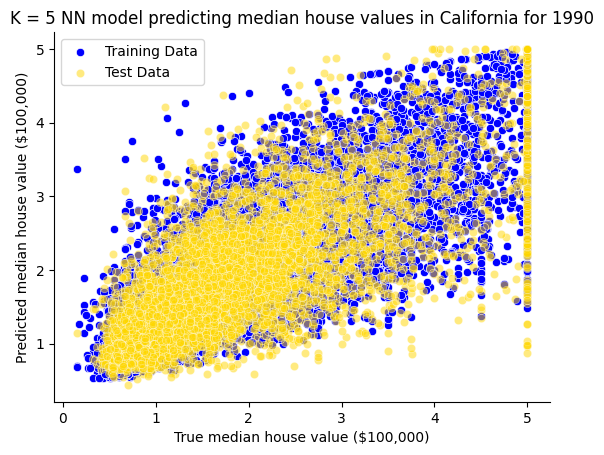

In [19]:
# 1. Test Set
RMSE_NN5_test = compute_rmse(y_test,y_hat_test_NN5)
print('RMSE test data set: '+ str(RMSE_NN5_test))

# 2. Training Set
RMSE_NN5_training = compute_rmse(y_train,y_hat_train_NN5)
print('RMSE training data set: '+ str(RMSE_NN5_training))

# 3. Scatterplot
sns.scatterplot(x = y_train, y = y_hat_train_NN5, color = 'blue', label = 'Training Data')
sns.scatterplot(x = y_test, y = y_hat_test_NN5, color = 'gold', label = 'Test Data', alpha = 0.5)
plt.xlabel('True median house value ($100,000)')
plt.ylabel('Predicted median house value ($100,000)')
plt.title('K = 5 NN model predicting median house values in California for 1990')
sns.despine()
plt.show()

**ANSWERS**
1. Use your algorithm to predict the median home value of every instance in the test set. Report the RMSE ("test RMSE")
- The RMSE of the test data set is : 0.795
2. Use your algorithm to predict the median home value of every instance in the training set and report the training RMSE.
- The RMSE of the training data set is : 0.642
3. Create a scatter plot that shows the true value of each instance on the x-axis and the predicted value of each instance on the y-axis.
- see above
4. Report an estimate of the total time taken by your code to predict the nearest neighbors for all the values in the test data set.
- The run time is _6.44 secs_ for predicting all the values in the **test** data set.
5. How does the performance (test RMSE and total runtime) of your nearest neighbors algorithm compare to the baseline in part 1.3?
- The test RMSE (RMSE = 0.794) for the NN model using K = 5 neighbours is markedly lower than the baseline model using the average MedHouseVal from 1.3 (RMSE = 1.147). The runtime on the other hand, is much higher for the KNN model vs the baseline model. This is because with NN model we must hold the training data in memory and comapre each single point in the test array to all the instances in the training data. This process is much slower than just returning the mean MedHouseVal for each point in the test array. We sacrfice run time for better model performance.

### 2.5 Cross-Validation

How can we choose K without overfitting? As discussed during lecture time, one possible solution is to use [k-fold cross-validation][1] on the training sample.  Here you must implement a simple k-fold cross-validation algorithm yourself.  The function(s) you write here will be used several more times in this problem set, so do your best to write efficient code! 

Use 20-fold cross-validation and report the average RMSE for your K-nearest neighbors model using Euclidean distance with the same set of features used in 2.3 (`MedIncNorm, HouseAgeNorm and AveRoomsNorm`) and 5 neighbors (`K=5`)  as well as the total running time for the full run of 20 folds.  

In other words, randomly divide your training dataset (created in 1.2) into 20 equally-sized samples. For each of the 20 iterations (the "folds"), use 19 samples as "training data" (even though there is no training in k-NN!), and the remaining 1 sample for validation.  Compute the RMSE of that particular validation set, then move on to the next iteration.  

 - Report the average cross-validated RMSE across the 20 iterations and compare to the result you obtained in 2.3. What do you observe?
 - Report the runtime of your algorithm.How does it compare to your previous results?

[1]: http://en.wikipedia.org/wiki/Cross-validation_(statistics)
[2]: http://scikit-learn.org/stable/modules/cross_validation.html#cross-validation

**Note 1:** Runtime should not exceed a couple of minutes. If its taking longer then we strongly suggest you go back to your code and make it more efficient. 

**Note 2**: The sklearn package has a built-in [K-fold][2] iterator -- you should *not* be invoking that or any related algorithms in this section of the problem set.

**Note 3:** To perform any randomized operation, only use functions in the *numpy library (np.random)*. Do not use other packages for random functions.

In [29]:
# K fold cross validation functions 

def k_fold_split(df, n_folds):
    # shuffle indices
    idxs = np.arange(len(df))
    np.random.shuffle(idxs)  

    # calculate fold size and store fold idxs
    fold_size = int(len(df))// n_folds
    fold_indices = [idxs[i * fold_size: (i + 1) * fold_size] for i in range(n_folds)]
    
    # check to make sure all indices are included in the last fold
    fold_indices[-1] = np.concatenate([fold_indices[-1], idxs[n_folds * fold_size:]])

    return fold_indices

def k_fold_cv(cal_df_train, n_folds, K = 5, L = 2):
    
    # determine fold idxs 
    fold_idxs = k_fold_split(cal_df_train, n_folds)
    RMSE_folds = []
    
    # record start time of code 
    start_time = time.time()
    for n_fold, test_idxs in enumerate(fold_idxs):

        # Remove the test index array from the list
        train_indices = np.concatenate(fold_idxs[:n_fold] + fold_idxs[n_fold+1:])
        train_indices = train_indices.flatten()

        # get cal_df_train for current fold 
        cal_df_train_nfold = cal_df_train.iloc[train_indices]
        cal_df_test_nfold = cal_df_train.iloc[test_idxs]

        # define x train and y train 
        x_train = cal_df_train_nfold[['MedIncNorm', 'HouseAgeNorm', 'AveRoomsNorm']].values
        y_train = cal_df_train_nfold['MedHouseVal'].values
        x_test = cal_df_test_nfold[['MedIncNorm', 'HouseAgeNorm', 'AveRoomsNorm']].values
        y_test = cal_df_test_nfold['MedHouseVal'].values

        # Create and fit the model
        knn_model_fold = NN_model(K, L) 
        knn_model_fold.fit(x_train, y_train)
        y_hat_test_fold = knn_model_fold.predict(x_test)

        # Compute RMSE for this fold and add to list 
        RMSE_NN5_fold = compute_rmse(y_test,y_hat_test_fold)
        RMSE_folds.append(RMSE_NN5_fold)
    
    # Compute mean RMSE
    RMSE_mean = np.mean(RMSE_folds)
    print('Mean RMSE for ' + str(n_folds)+ '-fold cross validation is : ' +str(RMSE_mean))
    
    # record end time and compute run time 
    end_time = time.time()
    runtime = end_time - start_time
    print('Total run time:' + str(runtime))
    
    return  RMSE_folds, RMSE_mean


In [28]:
# Run the KNN 20-fold cross valdiated model on the cal_df_train data set 
RMSE_nfolds, RMSE_mean = k_fold_cv(cal_df_train, n_folds=20, K = 5, L = 2)

run time:0.878795862197876
run time:0.8798730373382568
run time:0.8706071376800537
run time:0.8957018852233887
run time:0.9591209888458252
run time:0.8601841926574707
run time:0.854248046875
run time:0.8639061450958252
run time:0.9212806224822998
run time:0.9296920299530029
run time:0.9367129802703857
run time:0.858264684677124
run time:0.8803520202636719
run time:0.8827040195465088
run time:0.872830867767334
run time:0.8789279460906982
run time:0.8952560424804688
run time:0.8629560470581055
run time:0.8736450672149658
run time:0.8723340034484863
Mean RMSE for 20-fold cross validation is : 0.7877338021676317
Total run time:17.775264978408813


 **ANSWERS 2.5**
 1. Report the average cross-validated RMSE across the 20 iterations and compare to the result you obtained in 2.4. What do you observe?
 - The mean cross-validated RMSE across the 20 iterations is : 0.7887 using the cal_df_training data set from 1.2. Compared to our results from 2.4 using k=5 folds and running the KNN model on the cal_df_test data set (RMSE = 0.794), we find that the RMSE is slightly smaller  when running the 20-fold cv KNN model. This is because we are averaging the RMSE over 20 folds where each instance in the original training set is used once in the test data set and several times in the training data set. Thereby this allows us to make a better model with lower RMSE.
 2. Report the runtime of your algorithm. How does it compare to your previous results?
 - The run time for the 20-fold cv KNN model was 17.5 seconds, this is quite a bit longer compared to the 6.163 seconds taken for the K=5 NN model run on the test data set. This is because we are esentially running the KNN model 20 times but in this case using a smaller training data set and smaller test data set. This is why its not 20*6.1 seconds. 

### 2.6 Using cross validation to find the optimal value for K

Compute the cross-validated RMSE for values of K between 1 and 25 using 10-fold cross-validation and L2 normalization.  Use the following features in your model: `MedIncNorm, HouseAgeNorm and AveRoomsNorm` .  Create a graph that shows how cross-validated RMSE changes as K increases from 1 to 25.  Label your axes, and summarize what you see.  What do you think is a reasonable choice of K for this model?

Finally, "train" a K-nearest neighbor model using the value of K that minimized the cross-validated RMSE and report the test RMSE. (Continue to use L2 normalization and the same set of features). How does the test RMSE compare to the cross-validated RMSE, and is this what you expected? 

**Note:** Runtime should not exceed ~30 min. If its taking longer then we strongly suggest you go back to your code and make it more efficient. 

In [30]:
# PART 1: Determine optimal value of k 

# define initial k values and number of folds 
k_values = [i for i in range(1, 26)]
n_folds = 10
L = 2

# run k_fold_cv for varying values of k 
RMSE_kvals = []
for k in k_values:
    RMSE_nfolds, RMSE_mean = k_fold_cv(cal_df_train, n_folds, k, L)
    RMSE_kvals.append(RMSE_mean)


run time:1.6701240539550781
run time:1.69535493850708
run time:1.6593480110168457
run time:1.6723990440368652
run time:1.655730962753296
run time:1.6939010620117188
run time:1.645500898361206
run time:1.6827960014343262
run time:1.6717078685760498
run time:1.726963996887207
Mean RMSE for 10-fold cross validation is : 1.0221489076212449
Total run time:16.798141956329346
run time:1.7055349349975586
run time:1.6603190898895264
run time:1.6772701740264893
run time:1.6669270992279053
run time:1.6958529949188232
run time:1.6270880699157715
run time:1.6645970344543457
run time:1.6815168857574463
run time:1.683621883392334
run time:1.6749820709228516
Mean RMSE for 10-fold cross validation is : 0.8789357109919921
Total run time:16.763551235198975
run time:1.6607940196990967
run time:1.7281410694122314
run time:1.8642098903656006
run time:1.7012529373168945
run time:1.8679392337799072
run time:1.7376739978790283
run time:1.67085599899292
run time:1.6771509647369385
run time:1.7347021102905273
ru

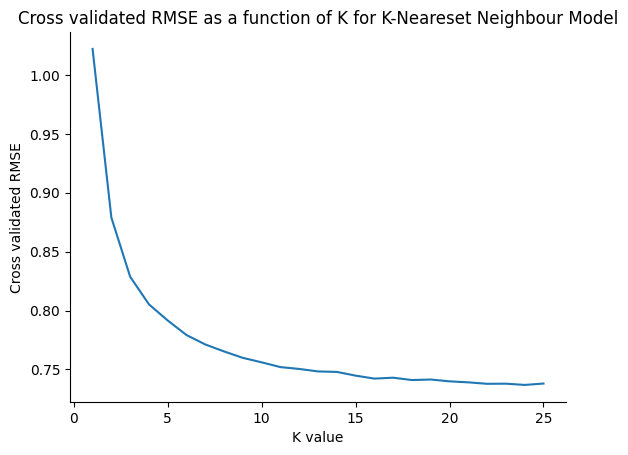

In [33]:
## Part 1: graph cv_RMSE as a function of k 
sns.lineplot(x = k_values, y = RMSE_kvals)
plt.xlabel('K value')
plt.ylabel('Cross validated RMSE')
plt.title('Cross validated RMSE as a function of K for K-Neareset Neighbour Model')
sns.despine()
plt.show()


*ANSWERS 2.6 PART 1*
1. Create a graph that shows how cross-validated RMSE changes as K increases from 1 to 25.  Label your axes, and summarize what you see.  
- Based on the graph above we find that relationship between cv-RMSE and k is a negative exponential, whereby the RMSE drops drastically as K increases from 1 to 5. The RMSE changes very little after k > 10, reaching a plateau
2. What do you think is a reasonable choice of K for this model?
- Based on the graph above, a reasonable choice of K is around 6 since it is a critical value of k that still achieves a large drop in RMSE without considering too many neighbours. Larger values of K may increase the model run time with larger data sets and do not lead to much greater changes in cv_RMSE. Therfore K = 6 is a good choice since its the best "bang for you buck". Note this i not the optimal value of k that minimizes the RMSE. Simply the reccomended one. The optimal value of K is 24.

In [38]:
# PART 2: K-nearest neighbor model using optimal value of K*
# determine K that minimized RMSE
k_star = k_values[np.argmin(RMSE_kvals)]

# convert x,y train and x test to np arrays
x_train = cal_df_train[['MedIncNorm', 'HouseAgeNorm', 'AveRoomsNorm']].values
y_train = cal_df_train['MedHouseVal'].values
x_test = cal_df_test[['MedIncNorm', 'HouseAgeNorm', 'AveRoomsNorm']].values
y_test = cal_df_test['MedHouseVal'].values

# Create and fit the model
knn_model_optk = NN_model(k=k_star, L=2) 
knn_model_optk.fit(x_train, y_train)
y_hat_test_optk = knn_model_optk.predict(x_test)

# Compute RMSE on test data set
RMSE_kopt_test = compute_rmse(y_test,y_hat_test_optk)
print('RMSE test data set: '+ str(RMSE_kopt_test))

run time:6.139597177505493
RMSE test data set: 0.7444404199437684


1. Finally, "train" a K-nearest neighbor model using the value of K that minimized the cross-validated RMSE and report the test RMSE. 
- The test RMSE for the KNN model using K = 24 that resulted in the minimzed cv-RMSE is : 0.744
2. How does the test RMSE compare to the cross-validated RMSE, and is this what you expected? 
- The test RMSE is 0.744 compared to the cross-validated RMSE = 0.737. This is slighlty higher which is indeed expected since here we are not performing cross-validation but rather testing our model on a new held out "test" data set that wasn't used in one of the folds during "training". Therefore we expect the RMSE to be higher. 

---

# Part III: Overfitting in Model Selection and Nested Cross Validation 


In this last part of the problem set, we will examine why overfitting is a serious concern when estimating hyperparameters and how to address it. 

**For this part of the problem set you are allowed to use machine learning libraries. We don't expect you to use your own algorithms developed in part 2.** We strongly suggest that you use the following libraries and resources, but feel free to choose your favorite Python ML libraries.

In [154]:
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
import joblib

For this part of the problem set we will no longer be using the California Housing Dataset. Instead, we will generate our own synthetic data. The advantage of doing so is that we get to choose the data generating process. We will use the knowledge about the data generating process to test the robustness of different approaches to estimating out-of-sample performance.

We will attempt the following classification problem: predict a binary response variable $y \sim Bernoulli(p=1/2)$ from a set of independent features $X=[x_{1},...,x_{J}]$ where $x_{j} \sim Unif(a=0,b=1)$, $1 \leq j \leq J$. 

You can use the following function to generate samples from this distribution.

In [155]:
def generate_random_sample(nobs,J):
    X = pd.DataFrame(np.random.random_sample(size=(nobs, J)), columns=[f'feature_{x}' for x in range(J)])
    y = np.random.binomial(n=1,p=1/2,size=nobs)
    return X,y

X_train,y_train = generate_random_sample(nobs=2*10**3,J=100)

### 3.1 Out-of-sample performance

We are going to be using the area under the ROC curve (AUC-ROC) as the evaluation score. What kind of out-of-sample performance would you expect from classification models trained and tested on this data? Test whether your intuition is correct by carrying out the following iterative procedure:

1. For each iteration in 1,2,3,...,50:
    * Generate a training sample containing 2,000 observations and J=100 features. Likewise, generate a test sample containing 200 observations and J=100 features. 
    * Train some K-nearest neighbors model on the training sample with some arbitrary choice of K (no need to cross validate the choice of K or put any work into it, we'll get to that later on).
    * Evaluate the AUC-ROC on the test set.
2. Plot a histogram of the test AUC-ROC scores.
3. Report the average of the test AUC-ROC scores.

In [156]:
# 1. Iterate 50 times to generate AUC-ROC scores
ROC_AUC_all = []
for i in range(1, 51):
    # define training and test data sets
    X_train,y_train = generate_random_sample(nobs=2000,J=100)
    X_test,y_test = generate_random_sample(nobs=200,J=100)

    # train KNN model on training sample using default k = 5
    knn_model = KNeighborsClassifier()
    knn_model.fit(X_train.values, y_train)

    # Predict response variable for test data set
    y_prob = knn_model.predict(X_test.values)

    # Calculate ROC AUC score
    roc_auc = roc_auc_score(y_test, y_prob)
    ROC_AUC_all.append(roc_auc)


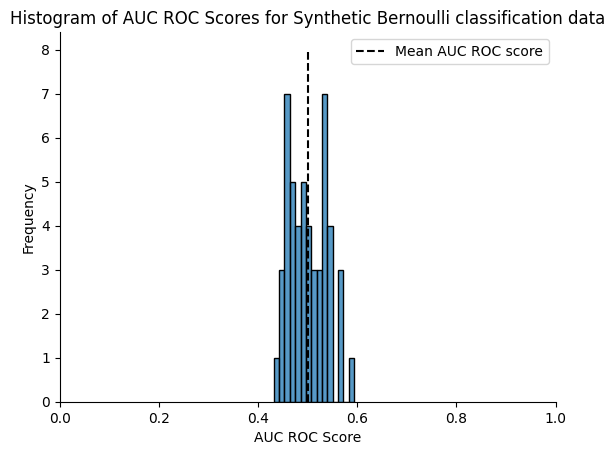

Mean test AUC-ROC score : 0.5005357836903355


In [157]:
# 2. Make histogram for test AUC-ROC scores

# Plot histogram
sns.histplot(ROC_AUC_all, bins = 15)
plt.title('Histogram of AUC ROC Scores for Synthetic Bernoulli classification data')
plt.xlabel('AUC ROC Score')
plt.ylabel('Frequency')
plt.vlines(np.mean(ROC_AUC_all), 0, 8, linestyles = 'dashed', color = 'black', label = 'Mean AUC ROC score')
plt.xlim([0,1])
sns.despine()
plt.legend()
plt.show()
print('Mean test AUC-ROC score : '+ str(np.mean(ROC_AUC_all)))



*ANSWERS 3.1*
1. What kind of out-of-sample performance would you expect from classification models trained and tested on this data?
- Given we are predicting a binary response variable $y \sim Bernoulli(p=1/2)$ with probability = 0.5, from a set of independent features that are uniformily distributed, I would expect that the classification model would achieve an AUC ROC score of around 0.5 at around chance levels. This is consistent with our findings after 50 iterations of running our model and obtaining a mean AUC-ROC score of 0.5005. The rationale for this is that since the features are uniformly distributed, the feature space will be evenly spread out, leading to regions of mixed classes. This makes it hard for the KNN classifier to find patterns of distinct clusters of classes, thereby leading to inaccurate predictions and thus a model score at chance levels. 

### Fix a sample

In real life settings we wouldn't be able to draw test and train samples at will. For the rest of the pset (3.2-3.6) we will fix a training and test sample:

In [158]:
X_train,y_train = generate_random_sample(nobs=2*10**3,J=100)
X_test,y_test = generate_random_sample(nobs=2*10**2,J=100)

### 3.2 k-fold cross-validation 
Use 10-fold cross-validation on the train sample to find the optimal K and report the hyperparameter value. Report also the average of the cross validated scores for the optimal hyperparameter value. 

In [169]:
# Range of k values to test
k_values = list(range(1, 26))

# Initialize list for mean cross-validation scores for each k value
cv_scores_mean = []

# Perform 10-fold cross-validation for each value of k
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    folds = KFold(n_splits=10, shuffle=True) # shufle data indices

    # compute cv-score and take mean before adding to list  
    k_score = cross_val_score(knn_k, X_train, y_train, cv=folds, scoring='accuracy')
    cv_scores_mean.append(k_score.mean())

# Find the optimal k value with the highest mean cross-validation score
optimal_k = k_values[np.argmax(cv_scores_mean)]

print('Optimal value of the K hyperparameter is :' + str(optimal_k) + ' with a mean cv-score of : ' + str(np.max(cv_scores_mean)))

Optimal value of the K hyperparameter is :16 with a mean cv-score of : 0.5065000000000002


**ANSWER 3.2**
- The optimal value of the K hyperparameter is 16 with a mean cv-score of : 0.5065

### 3.3 Nested cross-validation

Use nested cross validation ([3],[4],[5],[6]) on the training sample. In the outer loop you should be estimating model performance and in the inner loop you should be doing regular k-fold cross validation to find the optimal K. Use 10 folds for the inner cv and 3 folds for the outer cv. Report the average of the cross-validated scores of the outer loop.

[3]: https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html#sphx-glr-auto-examples-model-selection-plot-nested-cross-validation-iris-py
[4]: https://inria.github.io/scikit-learn-mooc/python_scripts/cross_validation_nested.html#:~:text=As%20a%20conclusion%2C%20when%20optimizing,validation%20are%20often%20overly%20optimistic.
[5]: https://stats.stackexchange.com/questions/65128/nested-cross-validation-for-model-selection/65156#65156
[6]: https://stats.stackexchange.com/questions/232897/how-to-build-the-final-model-and-tune-probability-threshold-after-nested-cross-v/233027#233027

In [168]:
# Use the same range of k values from 3.2 (up to 25)
param_grid = {'n_neighbors': k_values}

# Initialize list to store cv scores,
outer_cv_score = []
inner_cv_score = []

# define cv folds for inner and outer loop
outer_folds = KFold(n_splits=3, shuffle=True)
inner_folds = KFold(n_splits=10, shuffle=True)

# Define KNN model 
knn = KNeighborsClassifier()

# inner loop parameter search and scoring
grid_search = GridSearchCV(
    estimator=knn, param_grid=param_grid, cv=inner_folds)
grid_search.fit(X_train, y_train)
inner_cv_score.append(grid_search.best_score_)


# Nested CV with parameter optimization
test_score = cross_val_score(grid_search, X_train, y_train, cv=outer_folds, scoring='accuracy')
outer_cv_score.append(test_score.mean())
print('Average cross-validated score of outer loop:  ' + str(outer_cv_score[0]))

Average cross-validated score of outer loop:  0.4934957446201824


**ANSWER 3.3**
- The average cross-validated score of the outer loop for this nested cv is 0.493

### 3.4 Take stock of the results so far

Based on the results of 3.1, 3.2 and 3.3, what can you say about estimating out-of-sample performance? Is the average of the cross-validated scores a good estimator? How about the average of the nested cross-validated scores? Are they underestimating or overestimating true out-of-sample performance?


1. What can you say about estimating out-of-sample performance? 
- These are 3 different methods( AUC-ROC, k-fold cross validation and nested cross validation score) for estimating out of sample performance of our model. The AUC ROC scalar value assesses the model's __discrimination ability__, analyzing the tradeoff between the true positive and false positive rates and can be used to evaluate binary classifiers. This method evaluates out-of-sample performance from a discriminability standpoint. The mean test AUC-ROC score was 0.50053 which is near chance levels as is expected given the way we generated our data (expected 0.5 )

- K-fold cross-validation estimates the model's __generalizability__ by averaging performance across multiple folds. In 3.2 the mean 10-fold cv score was 0.5065 which is fairly close to the the expected model performance score but a slighlty larger score than what we obtained with the AUC ROC analysis. k-fold cross validation and nested cross validation scores assess out-of-sample performance from a generalization ability vs AUC-ROC score.

- Nested cross valdiation is useful for optimizing model hyperparameters (like K in our KNN algorithm) while also estimating the generalization error. In 3.3 we got a mean cv-score of 0.4934 for the outer loop, which is fairly close to the expected performance of the model (0.5), however slighlty underestimating this value. 

2. Is the average of the cross-validated scores a good estimator? Is it underestimating or overestimating true out-of-sample performance?
- Yes, it can serve as a good estimator of out-of-sample performance, but its reliability and tendency to underestimate /overestimate true out-of-sample performance depends on several factors. For a large and representative dataset where the model is stable and well-tuned, the mean cross-validated score is a good estimator. However if the model is not well tuned or if the same data is used to tune model hyperparameters simultaneously while evaluating model performance, this may lead to over-estimating the true generalization performance of the model. We see a bit of an overestimation in 3.2 with this evaluation method where we get a larger score (0.5065).

3. How about the average of the nested cross-validated scores? Is it underestimating or overestimating true out-of-sample performance?
- The average of the nested cross-validated scores is probably the most robust method for assessing out-of-sample performance. This is especially true for models requiring tuning of several hyperparameters since it more accurtely estimates true out-of-sample performance by utilizing an outer cross-validation procedure that assess the generalizability of the model during the learning procedure and tuning of the hyperparameters. This method mitigates the risk of overfitting and may lead to under-estimating model performance since it uses more conservative measures. This once again depends on the size of the data set and how accurately represents the population. 

### 3.5 Comparing k-fold and nested cross-validation [extra-credit]

We would like to better assess the difference between the k-fold and nested cross-validation scores and make sure that the results we observed in 3.2 and 3.3 are not a fluke. To do this, repeat both experiments 50 times. In each iteration, pass a different value for the "random_state" parameter in the KFold function to ensure that there is variation in the fold splitting. 

In a single figure, plot two histograms. One showing the distribution of the k-fold scores, another showing the distribution of the nested scores. Use gold for the color of the objects related to the nested scores and blue for the color of the objects related to the k-fold scores. 

**Note 1**: you should NOT be generating a new sample -- continue working with the dataset fixed ahead of question 3.2.

**Note 2**: Runtime should not exceed 30 min. If its taking longer then we strongly suggest you go back to your code and make it more efficient.

In [ ]:
# Repeat 3.2 with N = 50 trials 

# Range of k values to test
k_values = list(range(1, 26))
n_trials = 50

# Initialize list for mean cross-validation scores for each k value
cv_scores_folds = []
optimal_k_folds = []

# Run 10-fold cross-validation for N = 50 trials 
for n in range(n_trials):
    cv_scores_mean = []
    # Perform 10-fold cross-validation for each value of k
    for k in k_values:
        knn_k = KNeighborsClassifier(n_neighbors=k)
        folds = KFold(n_splits=10, shuffle=True, random_state = n) # shufle data indices

        # compute cv-score and take mean before adding to list  
        k_score = cross_val_score(knn_k, X_train, y_train, cv=folds, scoring='accuracy')
        cv_scores_mean.append(k_score.mean())

    # Find the optimal k value with the highest mean cross-validation score
    optimal_k = k_values[np.argmax(cv_scores_mean)]
    optimal_k_folds.append(optimal_k)

    # average of the cross validated score for the optimal hyperparameter value
    cv_scores_folds.append(np.max(cv_scores_mean))

print('Mean of average of the cross validated score for the optimal hyperparameter value :' + str(np.mean(cv_scores_folds)))

In [171]:
# Repeat 3.3 with N = 50 trials 

# Use the same range of k values from 3.2 (up to 25)
param_grid = {'n_neighbors': k_values}
n_trials = 50

# Initialize list to store cv scores,
outer_cv_score = []
inner_cv_score = []


# Define KNN model 
knn = KNeighborsClassifier()

for n in range(n_trials):

    # define cv folds for inner and outer loop
    outer_folds = KFold(n_splits=3, shuffle=True, random_state = n)
    inner_folds = KFold(n_splits=10, shuffle=True, random_state = n)

    # inner loop parameter search and scoring
    grid_search = GridSearchCV(
        estimator=knn, param_grid=param_grid, cv=inner_folds)
    grid_search.fit(X_train, y_train)
    inner_cv_score.append(grid_search.best_score_)

    # Nested CV with parameter optimization
    test_score = cross_val_score(grid_search, X_train, y_train, cv=outer_folds, scoring='accuracy')
    outer_cv_score.append(test_score.mean())
print('Average cross-validated score of outer loop:  ' + str(np.mean(outer_cv_score)))

Average cross-validated score of outer loop:  0.4884906345625985


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


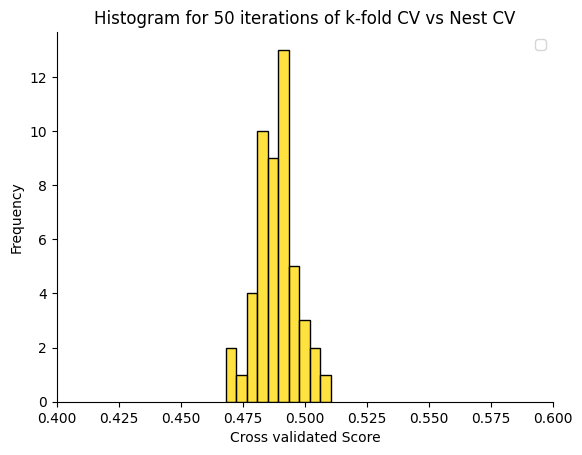

In [176]:
# 2. Make histogram for above 

# Plot histogram
sns.histplot(cv_scores_folds, bins = 15, color = 'blue')
sns.histplot(outer_cv_score, bins = 10, color = 'gold')

plt.title('Histogram for 50 iterations of k-fold CV vs Nest CV')
plt.xlabel('Cross validated Score')
plt.ylabel('Frequency')
plt.xlim([0.4,0.6])
sns.despine()
plt.legend()
plt.show()


### 3.6 Conclusion [extra-credit]

Based on the figure from 3.5, would you adjust your answer to question 3.4? In a couple of sentences, explain why overfitting can arise when doing model selection, and why nested cross-validation is a useful tool in preventing it. 

Nested cross valdiation is useful for preventing overfitting since it optimizes model hyperparameters while also estimating the generalization error. It more accurtely estimates true out-of-sample performance by utilizing an outer cross-validation procedure that assess the generalizability of the model during the learning procedure and tuning of the hyperparameters. This method tends to be more conservative, perhaps under-estimating model performance for stable and large datsets. 